<a href="https://colab.research.google.com/github/aabyyaann/Practical-Statistics-for-Data-Scientists/blob/main/Chapter04_Regression_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4 — Regression and Prediction

## Tujuan Chapter

Pada chapter ini kita mempelajari teknik regresi yang digunakan untuk memodelkan hubungan antar variabel dan melakukan prediksi.

Topik yang dipelajari:

1. Simple Linear Regression
2. Regression Equation
3. Residuals
4. Fitted Values
5. Multiple Linear Regression
6. Dummy Variables
7. Prediction
8. RMSE
9. R² Score
10. Overfitting

Regression merupakan fondasi utama dalam Machine Learning dan Data Science.

# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

np.random.seed(42)

# Dataset Contoh

Kita membuat data sederhana untuk mempelajari hubungan antara luas rumah dan harga rumah.

In [2]:
house = pd.DataFrame({
    "Size":[50,60,70,80,90,100,110,120],
    "Price":[150,180,210,240,270,300,330,360]
})

house

,Size,Price
0,50,150
1,60,180
2,70,210
3,80,240
4,90,270
5,100,300
6,110,330
7,120,360


# Visualisasi Data

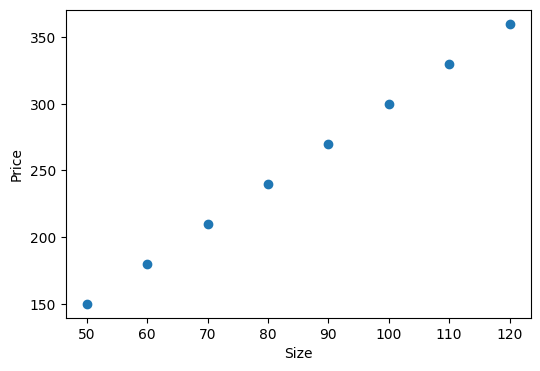

In [3]:
plt.figure(figsize=(6,4))

plt.scatter(
    house["Size"],
    house["Price"]
)

plt.xlabel("Size")
plt.ylabel("Price")

plt.show()

# 1. Simple Linear Regression

Model regresi linear sederhana:

\[
y = \beta_0 + \beta_1x
\]

dimana:

- y = target
- x = predictor
- β₀ = intercept
- β₁ = slope

In [4]:
X = house[["Size"]]

y = house["Price"]

In [5]:
model = LinearRegression()

model.fit(X,y)

LinearRegression()

# Parameter Model

In [6]:
print("Intercept :", model.intercept_)
print("Slope :", model.coef_[0])

Intercept : -2.842170943040401e-14
Slope : 3.0000000000000004


# Persamaan Regresi

In [7]:
print(
    f"Price = {model.intercept_:.2f} + ({model.coef_[0]:.2f}) × Size"
)

Price = -0.00 + (3.00) × Size


# 2. Fitted Values

Fitted values adalah hasil prediksi model terhadap data training.

In [8]:
y_pred = model.predict(X)

y_pred

array([150., 180., 210., 240., 270., 300., 330., 360.])

# Visualisasi Garis Regresi

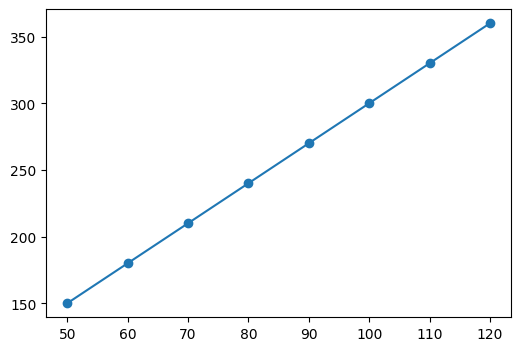

In [9]:
plt.figure(figsize=(6,4))

plt.scatter(
    X,
    y
)

plt.plot(
    X,
    y_pred
)

plt.show()

# 3. Residuals

Residual:

\[
Residual = Actual - Predicted
\]

Residual menunjukkan error model.

In [10]:
residuals = y - y_pred

residuals

,Price
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0


# Statistik Residual

In [11]:
print(residuals.describe())

count    8.0
mean     0.0
std      0.0
min      0.0
25%      0.0
50%      0.0
75%      0.0
max      0.0
Name: Price, dtype: float64


# Visualisasi Residual

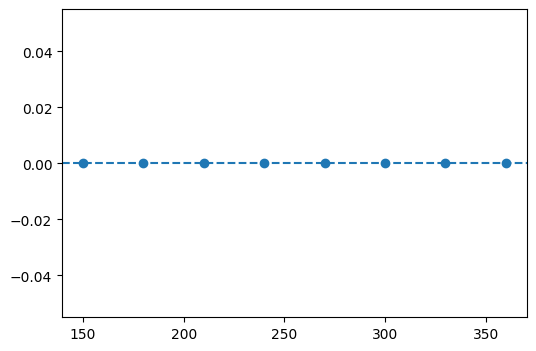

In [12]:
plt.figure(figsize=(6,4))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.show()

# Interpretasi

Residual yang tersebar acak menunjukkan model cukup baik.

# 4. Prediction

In [13]:
new_house = [[130]]

prediction = model.predict(
    new_house
)

print(prediction)

[390.]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Interpretasi

Model memperkirakan harga rumah berdasarkan ukuran rumah.

# 5. Mean Squared Error (MSE)

\[
MSE=
\frac{\sum(y-\hat y)^2}{n}
\]

In [14]:
mse = mean_squared_error(
    y,
    y_pred
)

print(mse)

0.0


# Root Mean Squared Error (RMSE)

In [15]:
rmse = np.sqrt(mse)

print(rmse)

0.0


# Interpretasi RMSE

Semakin kecil RMSE maka model semakin baik.

# 6. R² Score

R² mengukur proporsi variasi data yang dapat dijelaskan model.

In [16]:
r2 = r2_score(
    y,
    y_pred
)

print(r2)

1.0


# Interpretasi

Nilai R² berada pada rentang:

\[
0 \le R^2 \le 1
\]

Semakin mendekati 1 semakin baik.

# 7. Multiple Linear Regression

Menggunakan lebih dari satu variabel prediktor.

In [17]:
multi_df = pd.DataFrame({
    "Size":[50,60,70,80,90,100],
    "Bedrooms":[1,2,2,3,3,4],
    "Price":[150,180,210,240,270,300]
})

multi_df

,Size,Bedrooms,Price
0,50,1,150
1,60,2,180
2,70,2,210
3,80,3,240
4,90,3,270
5,100,4,300


In [18]:
X_multi = multi_df[
    ["Size","Bedrooms"]
]

y_multi = multi_df["Price"]

In [19]:
multi_model = LinearRegression()

multi_model.fit(
    X_multi,
    y_multi
)

LinearRegression()

# Koefisien Model

In [20]:
print(
    multi_model.coef_
)

print(
    multi_model.intercept_
)

[3.00000000e+00 2.16158277e-17]
-2.842170943040401e-14


# Interpretasi

Setiap koefisien menunjukkan kontribusi masing-masing variabel terhadap target.

# 8. Dummy Variables

Variabel kategorikal harus diubah menjadi bentuk numerik.

In [21]:
category_df = pd.DataFrame({
    "Color":[
        "Red",
        "Blue",
        "Green",
        "Red"
    ]
})

pd.get_dummies(
    category_df
)

,Color_Blue,Color_Green,Color_Red
0,False,False,True
1,True,False,False
2,False,True,False
3,False,False,True


# 9. Overfitting

Overfitting terjadi ketika model terlalu mengikuti data training sehingga gagal melakukan generalisasi.

In [22]:
x = np.linspace(
    0,
    10,
    100
)

noise = np.random.normal(
    0,
    1,
    100
)

y = x**2 + noise

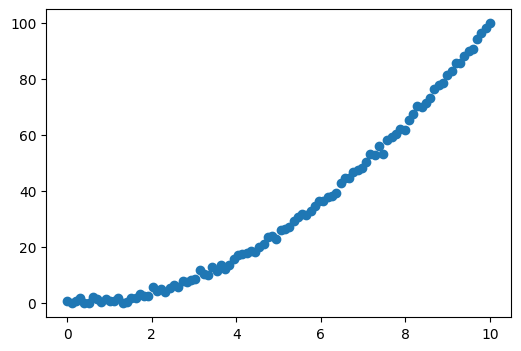

In [23]:
plt.figure(figsize=(6,4))

plt.scatter(
    x,
    y
)

plt.show()

# Tanda-Tanda Overfitting

- Error training sangat kecil
- Error testing besar
- Model terlalu kompleks

# Ringkasan Chapter 4

Pada chapter ini dipelajari:

- Simple Linear Regression
- Regression Equation
- Residual Analysis
- Prediction
- MSE
- RMSE
- R² Score
- Multiple Linear Regression
- Dummy Variables
- Overfitting

Regression merupakan salah satu teknik paling penting dalam statistik dan machine learning karena digunakan untuk memahami hubungan antar variabel dan melakukan prediksi.